<a href="https://colab.research.google.com/github/MDRobiulhassan/Mental-Health/blob/main/Mental_Health_Treatment_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [136]:
import numpy as np
import pandas as pd

In [137]:
df=pd.read_csv("/content/drive/MyDrive/University/7th Semester/MLL/Project/Mental Health Dataset.csv")

In [138]:
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [139]:
df.shape

(292364, 17)

# Data Preprocessing

In [140]:
df.duplicated().sum()

np.int64(2313)

In [141]:
df = df.drop_duplicates()

In [142]:
df.duplicated().sum()

np.int64(0)

In [143]:
df.isna().sum()

,0
Timestamp,0
Gender,0
Country,0
Occupation,0
self_employed,5193
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0


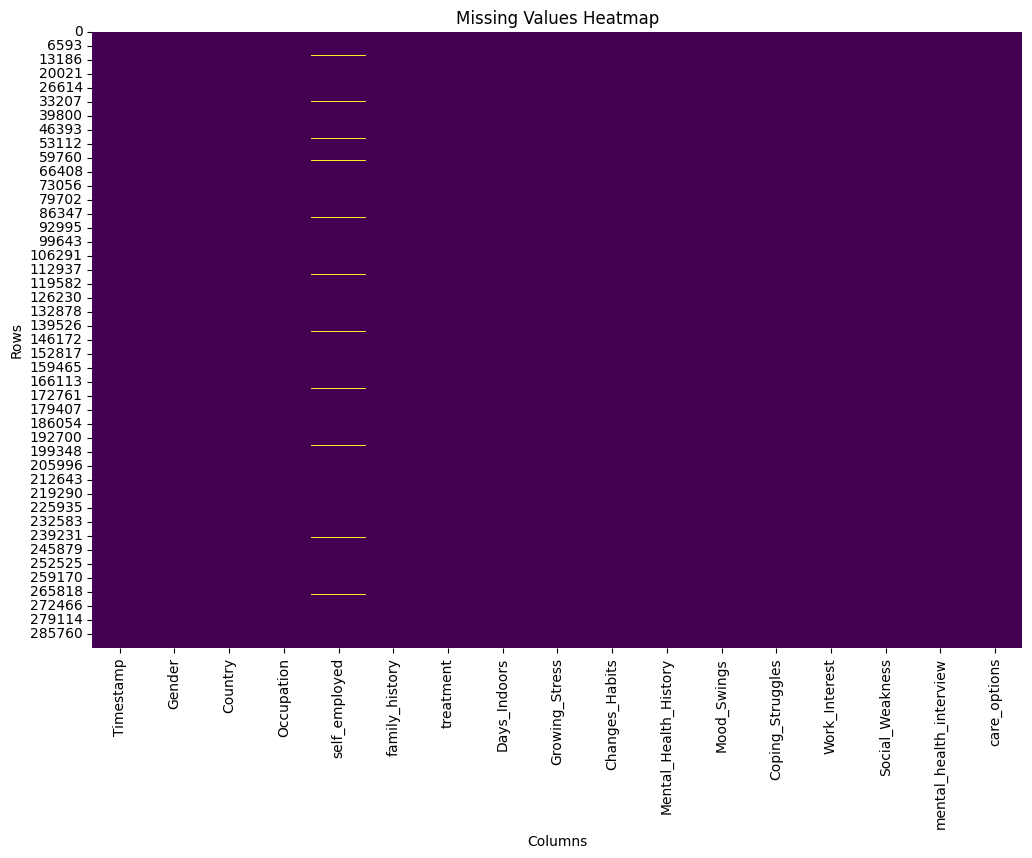

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.xlabel('Columns')
    plt.ylabel('Rows')
    plt.show()
else:
    print("No missing values to display in the heatmap.")

In [145]:
mode_self_employed = df['self_employed'].mode()[0]
df['self_employed'] = df['self_employed'].fillna(mode_self_employed)

print(f"Missing values in 'self_employed' filled with: {mode_self_employed}")

Missing values in 'self_employed' filled with: No


In [146]:
df.isna().sum()

,0
Timestamp,0
Gender,0
Country,0
Occupation,0
self_employed,0
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0


In [147]:
df = df.drop('Timestamp', axis=1)

## Encoding Categorical Features

In [148]:
df.dtypes

,0
Gender,object
Country,object
Occupation,object
self_employed,object
family_history,object
treatment,object
Days_Indoors,object
Growing_Stress,object
Changes_Habits,object
Mental_Health_History,object


In [149]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include='object').columns

label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

display(df.head())

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,0,34,1,0,0,1,0,2,1,2,2,0,1,2,1,1
1,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0
2,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2
3,0,34,1,0,1,1,0,2,1,2,2,0,1,2,0,2
4,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2


In [150]:
df.dtypes

,0
Gender,int64
Country,int64
Occupation,int64
self_employed,int64
family_history,int64
treatment,int64
Days_Indoors,int64
Growing_Stress,int64
Changes_Habits,int64
Mental_Health_History,int64


In [151]:
df.head()

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,0,34,1,0,0,1,0,2,1,2,2,0,1,2,1,1
1,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0
2,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2
3,0,34,1,0,1,1,0,2,1,2,2,0,1,2,0,2
4,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2


In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 290051 entries, 0 to 292363
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Gender                   290051 non-null  int64
 1   Country                  290051 non-null  int64
 2   Occupation               290051 non-null  int64
 3   self_employed            290051 non-null  int64
 4   family_history           290051 non-null  int64
 5   treatment                290051 non-null  int64
 6   Days_Indoors             290051 non-null  int64
 7   Growing_Stress           290051 non-null  int64
 8   Changes_Habits           290051 non-null  int64
 9   Mental_Health_History    290051 non-null  int64
 10  Mood_Swings              290051 non-null  int64
 11  Coping_Struggles         290051 non-null  int64
 12  Work_Interest            290051 non-null  int64
 13  Social_Weakness          290051 non-null  int64
 14  mental_health_interview  290051 non-null 

## Outlier Detection

In [153]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,290051.0,0.820201,0.384021,0.0,1.0,1.0,1.0,1.0
Country,290051.0,28.662570,10.213217,0.0,33.0,34.0,34.0,34.0
Occupation,290051.0,2.050301,1.385362,0.0,1.0,2.0,3.0,4.0
self_employed,290051.0,0.100489,0.300652,0.0,0.0,0.0,0.0,1.0
family_history,290051.0,0.394872,0.488824,0.0,0.0,0.0,1.0,1.0
treatment,290051.0,0.503994,0.499985,0.0,0.0,1.0,1.0,1.0
Days_Indoors,290051.0,1.962527,1.420416,0.0,1.0,2.0,3.0,4.0
Growing_Stress,290051.0,0.998176,0.826367,0.0,0.0,1.0,2.0,2.0
Changes_Habits,290051.0,1.049988,0.835252,0.0,0.0,1.0,2.0,2.0
Mental_Health_History,290051.0,0.992091,0.802341,0.0,0.0,1.0,2.0,2.0


In [154]:
outlier_info = {}

for column in df.columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_info[column] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count,
    }

outlier_df = pd.DataFrame(outlier_info).T
display(outlier_df)

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
Gender,1.0,1.0,0.0,1.0,1.0,52151.0
Country,33.0,34.0,1.0,31.5,35.5,69193.0
Occupation,1.0,3.0,2.0,-2.0,6.0,0.0
self_employed,0.0,0.0,0.0,0.0,0.0,29147.0
family_history,0.0,1.0,1.0,-1.5,2.5,0.0
treatment,0.0,1.0,1.0,-1.5,2.5,0.0
Days_Indoors,1.0,3.0,2.0,-2.0,6.0,0.0
Growing_Stress,0.0,2.0,2.0,-3.0,5.0,0.0
Changes_Habits,0.0,2.0,2.0,-3.0,5.0,0.0
Mental_Health_History,0.0,2.0,2.0,-3.0,5.0,0.0


In [155]:
columns_with_outliers = outlier_df[outlier_df['Outlier Count'] > 0].index.tolist()

if not columns_with_outliers:
    print("No outliers detected in any column based on the IQR method.")
else:
    print(f"Columns with outliers: {', '.join(columns_with_outliers)}")

Columns with outliers: Gender, Country, self_employed, mental_health_interview


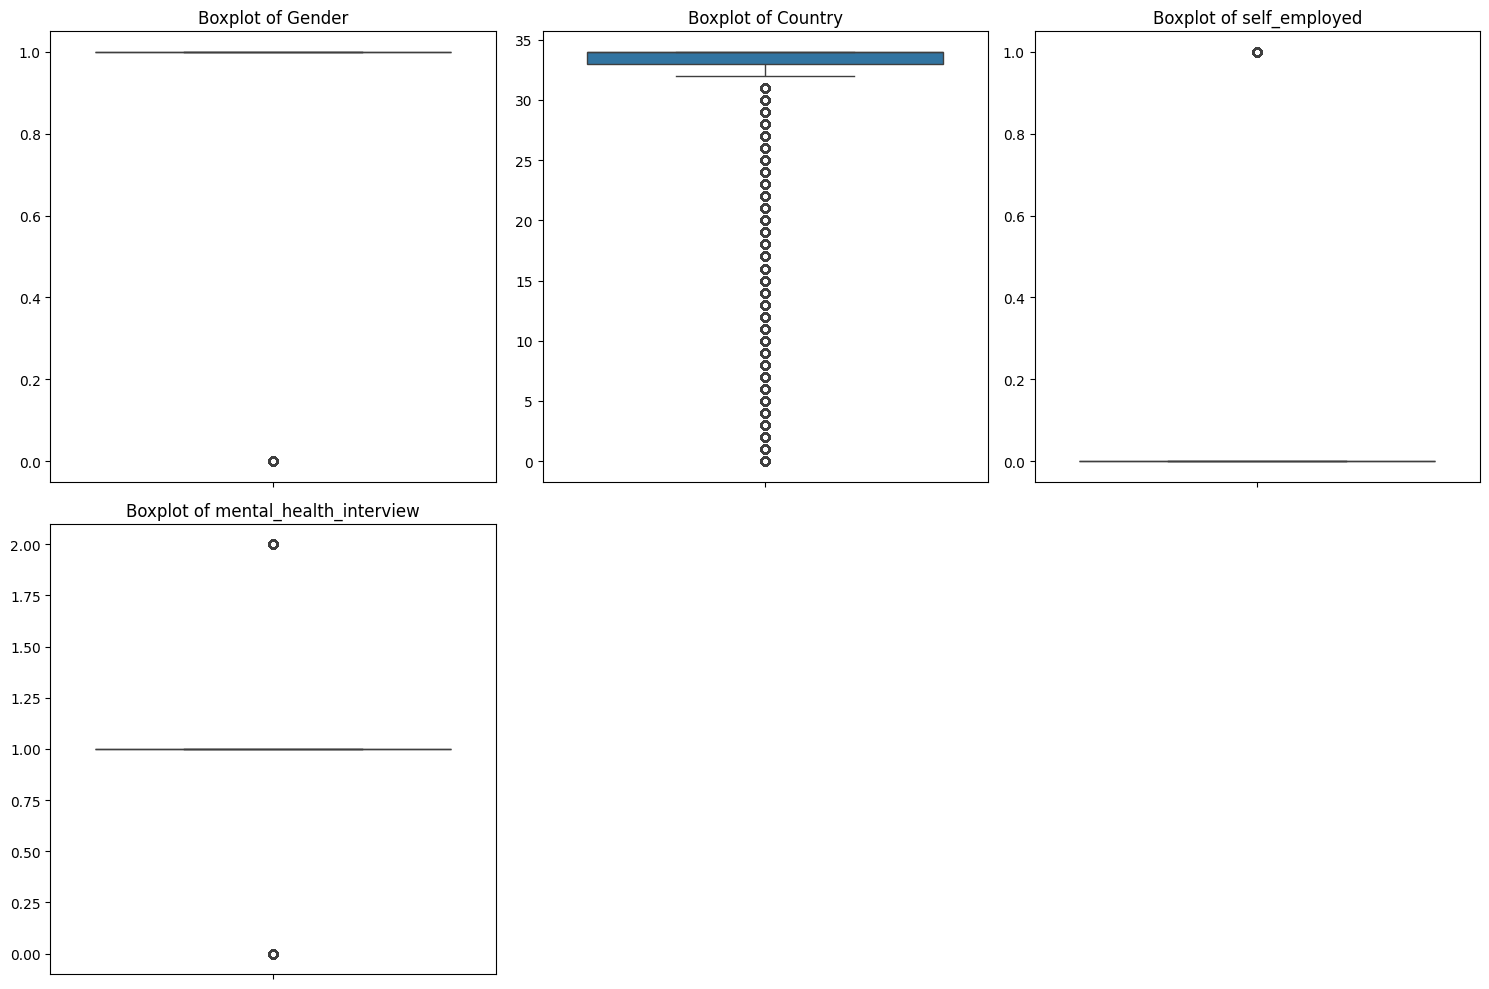

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

if columns_with_outliers:
    num_cols = len(columns_with_outliers)
    num_rows = (num_cols + 2) // 3
    plt.figure(figsize=(15, 5 * num_rows))

    for i, column in enumerate(columns_with_outliers):
        plt.subplot(num_rows, 3, i + 1)
        sns.boxplot(y=df[column])
        plt.title(f'Boxplot of {column}')
        plt.ylabel('')

    plt.tight_layout()
    plt.show()
else:
    print("No outliers to plot.")

## Multivariate Outlier Detection using Isolation Forest

In [157]:
from sklearn.ensemble import IsolationForest

# Initialize Isolation Forest model
# contamination: The proportion of outliers in the data set. This is used when fitting the model to define the threshold on the scores of the samples.
# A common practice is to estimate it or set it to a small value (e.g., 0.01 to 0.1)
isolation_forest = IsolationForest(random_state=42, contamination=0.05) # Assuming 5% outliers

# Create a copy of the DataFrame for fitting to ensure consistent features
# for prediction and decision_function.
df_for_if = df.copy()

# Fit the model (only fit)
isolation_forest.fit(df_for_if)

# Predict outliers and get anomaly scores using the fitted model on the original features
df['outlier_if'] = isolation_forest.predict(df_for_if)
df['anomaly_score'] = isolation_forest.decision_function(df_for_if)

print("Isolation Forest applied successfully.")
print(f"Number of outliers detected: {len(df[df['outlier_if'] == -1])}")
display(df.head())

Isolation Forest applied successfully.
Number of outliers detected: 14503


,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,outlier_if,anomaly_score
0,0,34,1,0,0,1,0,2,1,2,2,0,1,2,1,1,1,0.051116
1,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,1,0.037550
2,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2,1,0.039090
3,0,34,1,0,1,1,0,2,1,2,2,0,1,2,0,2,1,0.013405
4,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2,1,0.039090


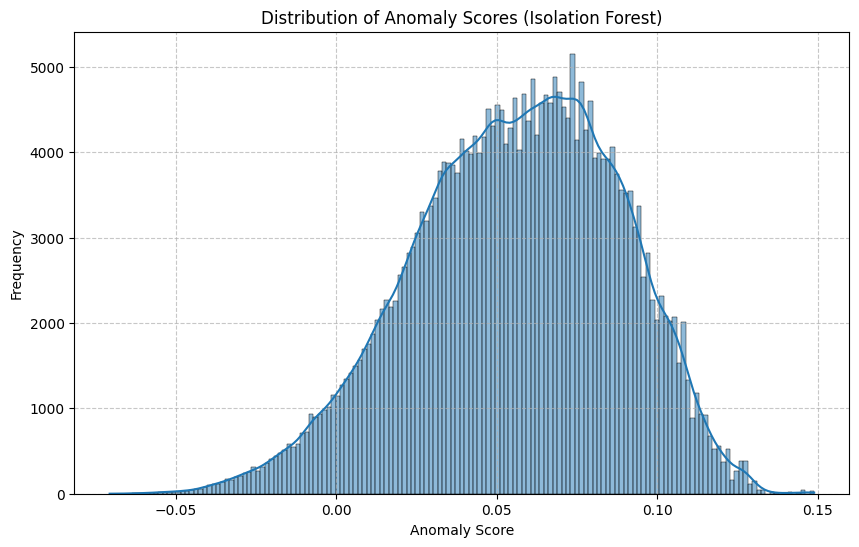

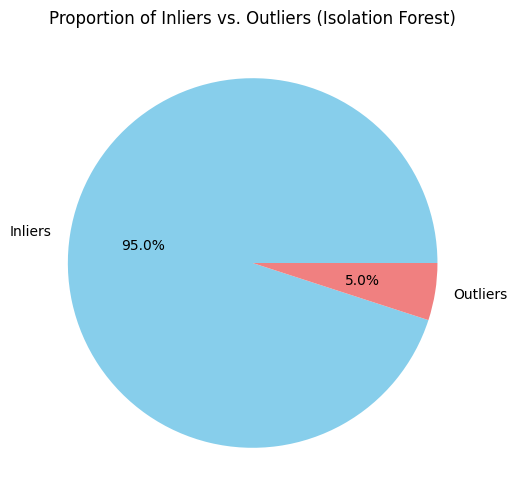

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of anomaly scores
plt.figure(figsize=(10, 6))
sns.histplot(df['anomaly_score'], kde=True)
plt.title('Distribution of Anomaly Scores (Isolation Forest)')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Visualize the proportion of outliers vs. inliers
plt.figure(figsize=(8, 6))
df['outlier_if'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], labels=['Inliers', 'Outliers'])
plt.title('Proportion of Inliers vs. Outliers (Isolation Forest)')
plt.ylabel('')
plt.show()